# Smart Industrial Health, Energy & Air Quality Monitoring System

## Problem Statement
This project aims to monitor industrial machine health, energy consumption, and air quality using data analysis techniques to detect anomalies and improve efficiency.

# Air Quality

In [26]:
import pandas as pd
import numpy as np

## Read Data

In [27]:
air_df = pd.read_csv("air_quality.csv")
energy_df = pd.read_csv("Steel_industry_data.csv")


## Data Overview

In [28]:
air_df.head()

,Date,City,CO,NO2,SO2,O3,PM2.5,PM10,Type
0,2024-01-01 00:00:00+00:00,Moscow,208.0,15.9,13.2,44.0,8.6,9.4,Industrial
1,2024-01-01 01:00:00+00:00,Moscow,207.0,17.4,13.7,44.0,8.6,10.5,Industrial
2,2024-01-01 02:00:00+00:00,Moscow,217.0,19.0,15.5,43.0,10.4,12.9,Industrial
3,2024-01-01 03:00:00+00:00,Moscow,231.0,21.0,20.7,36.0,12.3,15.3,Industrial
4,2024-01-01 04:00:00+00:00,Moscow,263.0,34.5,27.2,27.0,13.6,20.0,Industrial


## Data Understanding

In this step, we explore the structure, features, and basic statistics of the dataset to understand its composition before cleaning and analysis.

In [29]:
air_df.head()

,Date,City,CO,NO2,SO2,O3,PM2.5,PM10,Type
0,2024-01-01 00:00:00+00:00,Moscow,208.0,15.9,13.2,44.0,8.6,9.4,Industrial
1,2024-01-01 01:00:00+00:00,Moscow,207.0,17.4,13.7,44.0,8.6,10.5,Industrial
2,2024-01-01 02:00:00+00:00,Moscow,217.0,19.0,15.5,43.0,10.4,12.9,Industrial
3,2024-01-01 03:00:00+00:00,Moscow,231.0,21.0,20.7,36.0,12.3,15.3,Industrial
4,2024-01-01 04:00:00+00:00,Moscow,263.0,34.5,27.2,27.0,13.6,20.0,Industrial


In [30]:
air_df.shape

(8784, 9)

In [31]:
air_df.columns

Index(['Date', 'City', 'CO', 'NO2', 'SO2', 'O3', 'PM2.5', 'PM10', 'Type'], dtype='object')

In [32]:
air_df.dtypes

Date      object
City      object
CO       float64
NO2      float64
SO2      float64
O3       float64
PM2.5    float64
PM10     float64
Type      object
dtype: object

In [33]:
air_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    8784 non-null   object 
 1   City    8784 non-null   object 
 2   CO      8784 non-null   float64
 3   NO2     8784 non-null   float64
 4   SO2     8784 non-null   float64
 5   O3      8784 non-null   float64
 6   PM2.5   8784 non-null   float64
 7   PM10    8784 non-null   float64
 8   Type    8784 non-null   object 
dtypes: float64(6), object(3)
memory usage: 617.8+ KB


In [34]:
air_df.describe()

,CO,NO2,SO2,O3,PM2.5,PM10
count,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000
mean,346.096084,38.707252,36.447928,32.579804,25.737113,31.882571
std,189.003816,18.598074,26.427813,22.960966,17.528650,21.988919
min,141.000000,6.200000,5.700000,0.000000,4.200000,6.400000
25%,231.000000,25.000000,19.800000,14.000000,14.375000,17.600000
50%,286.000000,35.200000,28.400000,31.000000,21.200000,25.800000
75%,392.000000,49.000000,44.800000,47.000000,31.200000,38.700000
max,2267.000000,148.900000,285.900000,132.000000,200.500000,224.200000


## Data Cleaning

In this step, we handle missing values, remove duplicates, fix data types, and prepare the dataset for analysis.

In [35]:
air_df.isnull().sum()

Date     0
City     0
CO       0
NO2      0
SO2      0
O3       0
PM2.5    0
PM10     0
Type     0
dtype: int64

In [36]:
air_df.duplicated().sum()

np.int64(0)

## Data Cleaning

The dataset was checked for missing values, duplicates, and data consistency. No missing values were found, indicating a complete dataset. Further steps were performed to ensure data quality.

In [37]:
air_df.columns = air_df.columns.str.strip()

## Feature Engineering

Feature engineering involves creating new meaningful features from existing data to improve analysis and interpretation of air quality conditions.

### AQI Calculation

A simplified Air Quality Index (AQI) is calculated using weighted contributions of major pollutants such as PM2.5, PM10, NO2, and SO2.

In [38]:
air_df["AQI"] = (
    air_df["PM2.5"] * 0.4 +
    air_df["PM10"] * 0.3 +
    air_df["NO2"] * 0.2 +
    air_df["SO2"] * 0.1
)

### AQI Categorization

AQI values are categorized into different levels such as Good, Moderate, and Poor to simplify interpretation of air quality.

In [39]:
def categorize_aqi(aqi):
    if aqi <= 50:
        return "Good"
    elif aqi <= 100:
        return "Moderate"
    else:
        return "Poor"

air_df["AQI_Category"] = air_df["AQI"].apply(categorize_aqi)

### Pollution Intensity

A combined pollution intensity feature is created by summing major pollutants to represent the overall pollution load.

In [40]:
air_df["Pollution_Intensity"] = (
    air_df["PM2.5"] +
    air_df["PM10"] +
    air_df["NO2"] +
    air_df["SO2"] +
    air_df["CO"]
)

### PM Ratio

This feature represents the ratio of fine particulate matter (PM2.5) to coarse particulate matter (PM10), helping analyze pollution composition.

In [41]:
air_df["PM_Ratio"] = air_df["PM2.5"] / (air_df["PM10"] + 1)

### Updated Dataset

The dataset now includes new features such as AQI and PM Ratio for enhanced analysis.

In [42]:
air_df.head(50)

,Date,City,CO,NO2,SO2,O3,PM2.5,PM10,Type,AQI,AQI_Category,Pollution_Intensity,PM_Ratio
0,2024-01-01 00:00:00+00:00,Moscow,208.0,15.9,13.2,44.0,8.6,9.4,Industrial,10.76,Good,255.1,0.826923
1,2024-01-01 01:00:00+00:00,Moscow,207.0,17.4,13.7,44.0,8.6,10.5,Industrial,11.44,Good,257.2,0.747826
2,2024-01-01 02:00:00+00:00,Moscow,217.0,19.0,15.5,43.0,10.4,12.9,Industrial,13.38,Good,274.8,0.748201
3,2024-01-01 03:00:00+00:00,Moscow,231.0,21.0,20.7,36.0,12.3,15.3,Industrial,15.78,Good,300.3,0.754601
4,2024-01-01 04:00:00+00:00,Moscow,263.0,34.5,27.2,27.0,13.6,20.0,Industrial,21.06,Good,358.3,0.647619
5,2024-01-01 05:00:00+00:00,Moscow,352.0,49.5,34.2,12.0,17.6,25.8,Industrial,28.10,Good,479.1,0.656716
6,2024-01-01 06:00:00+00:00,Moscow,389.0,53.4,40.2,8.0,22.9,31.6,Industrial,33.34,Good,537.1,0.702454
7,2024-01-01 07:00:00+00:00,Moscow,429.0,54.9,45.7,10.0,24.9,29.7,Industrial,34.42,Good,584.2,0.811075
8,2024-01-01 08:00:00+00:00,Moscow,431.0,47.1,47.5,17.0,22.5,32.6,Industrial,32.95,Good,580.7,0.669643
9,2024-01-01 09:00:00+00:00,Moscow,434.0,43.9,48.1,21.0,22.9,39.5,Industrial,34.60,Good,588.4,0.565432


### Summary

New features such as AQI, AQI Category, and PM Ratio were created to enhance the dataset. These features help in better understanding and analyzing air quality conditions.

## Exploratory Data Analysis (EDA)

In this section, we analyze relationships between different air pollutants and visualize patterns using various graphs to gain insights into air quality conditions.

### Correlation Analysis

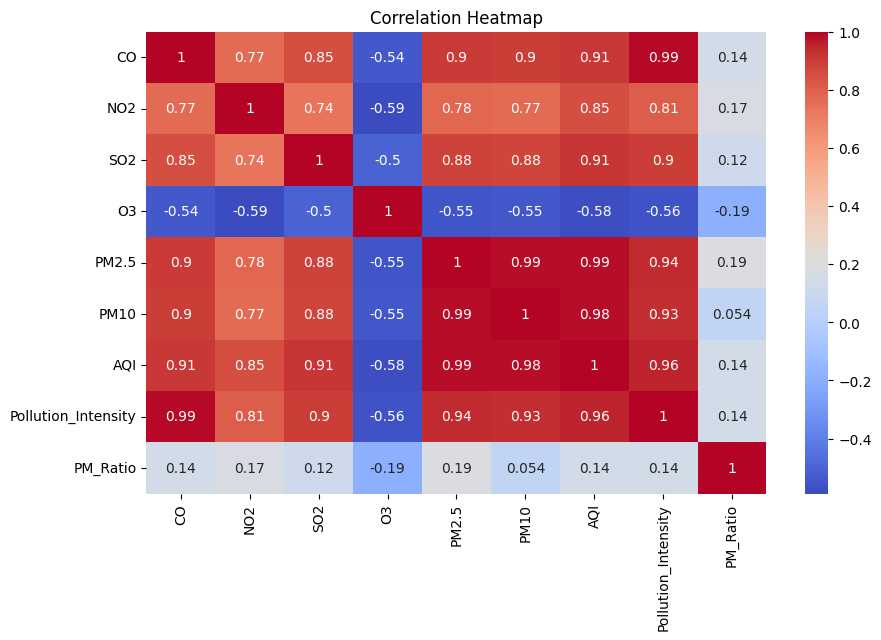

In [110]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.heatmap(air_df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

### Distribution of Pollutants

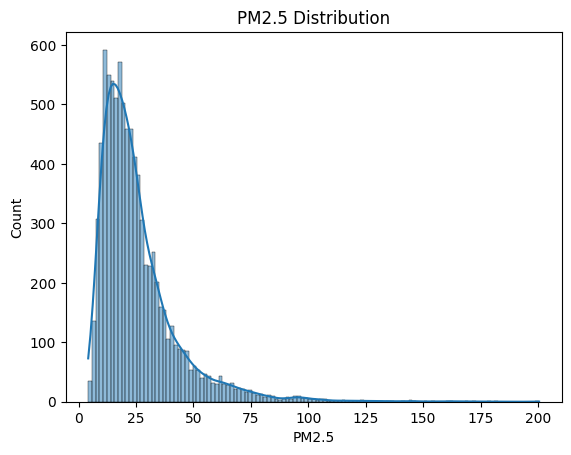

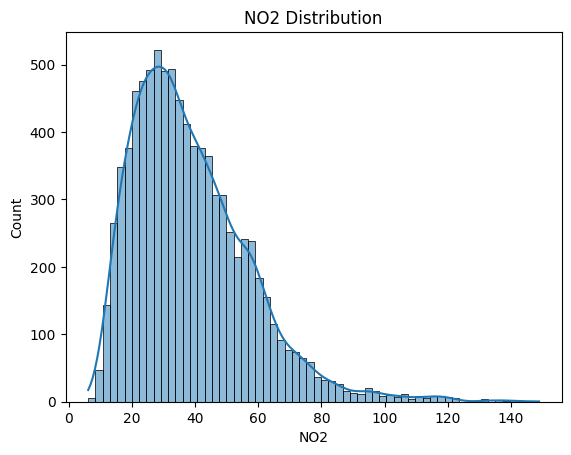

In [44]:
sns.histplot(air_df["PM2.5"], kde=True)
plt.title("PM2.5 Distribution")
plt.show()

sns.histplot(air_df["NO2"], kde=True)
plt.title("NO2 Distribution")
plt.show()

### Relationship Between Pollutants

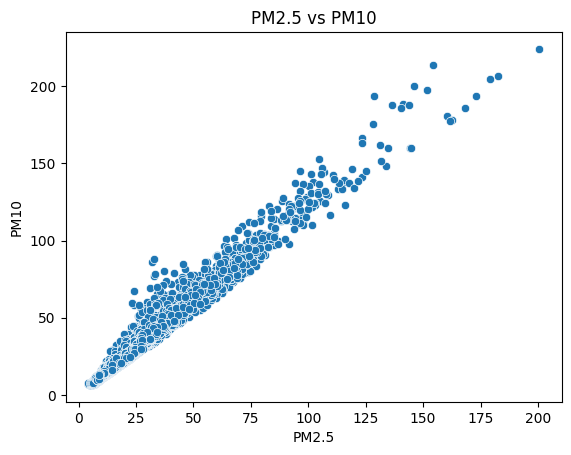

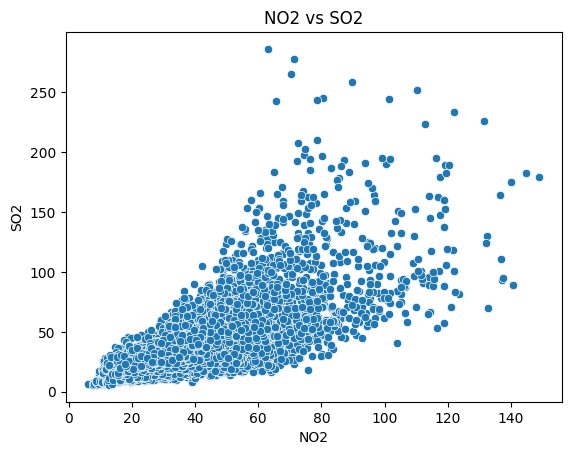

In [45]:
sns.scatterplot(x=air_df["PM2.5"], y=air_df["PM10"])
plt.title("PM2.5 vs PM10")
plt.show()

sns.scatterplot(x=air_df["NO2"], y=air_df["SO2"])
plt.title("NO2 vs SO2")
plt.show()

### AQI Distribution

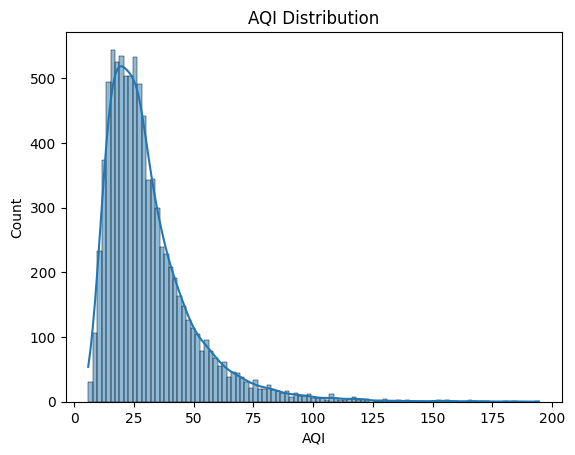

In [46]:
sns.histplot(air_df["AQI"], kde=True)
plt.title("AQI Distribution")
plt.show()

### Outlier Detection

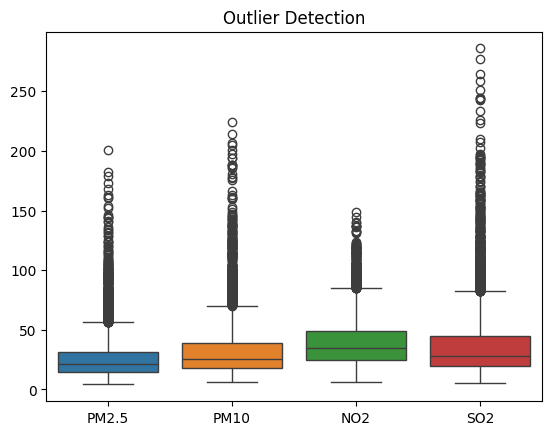

In [47]:
sns.boxplot(data=air_df[["PM2.5", "PM10", "NO2", "SO2"]])
plt.title("Outlier Detection")
plt.show()

### Pairplot Analysis

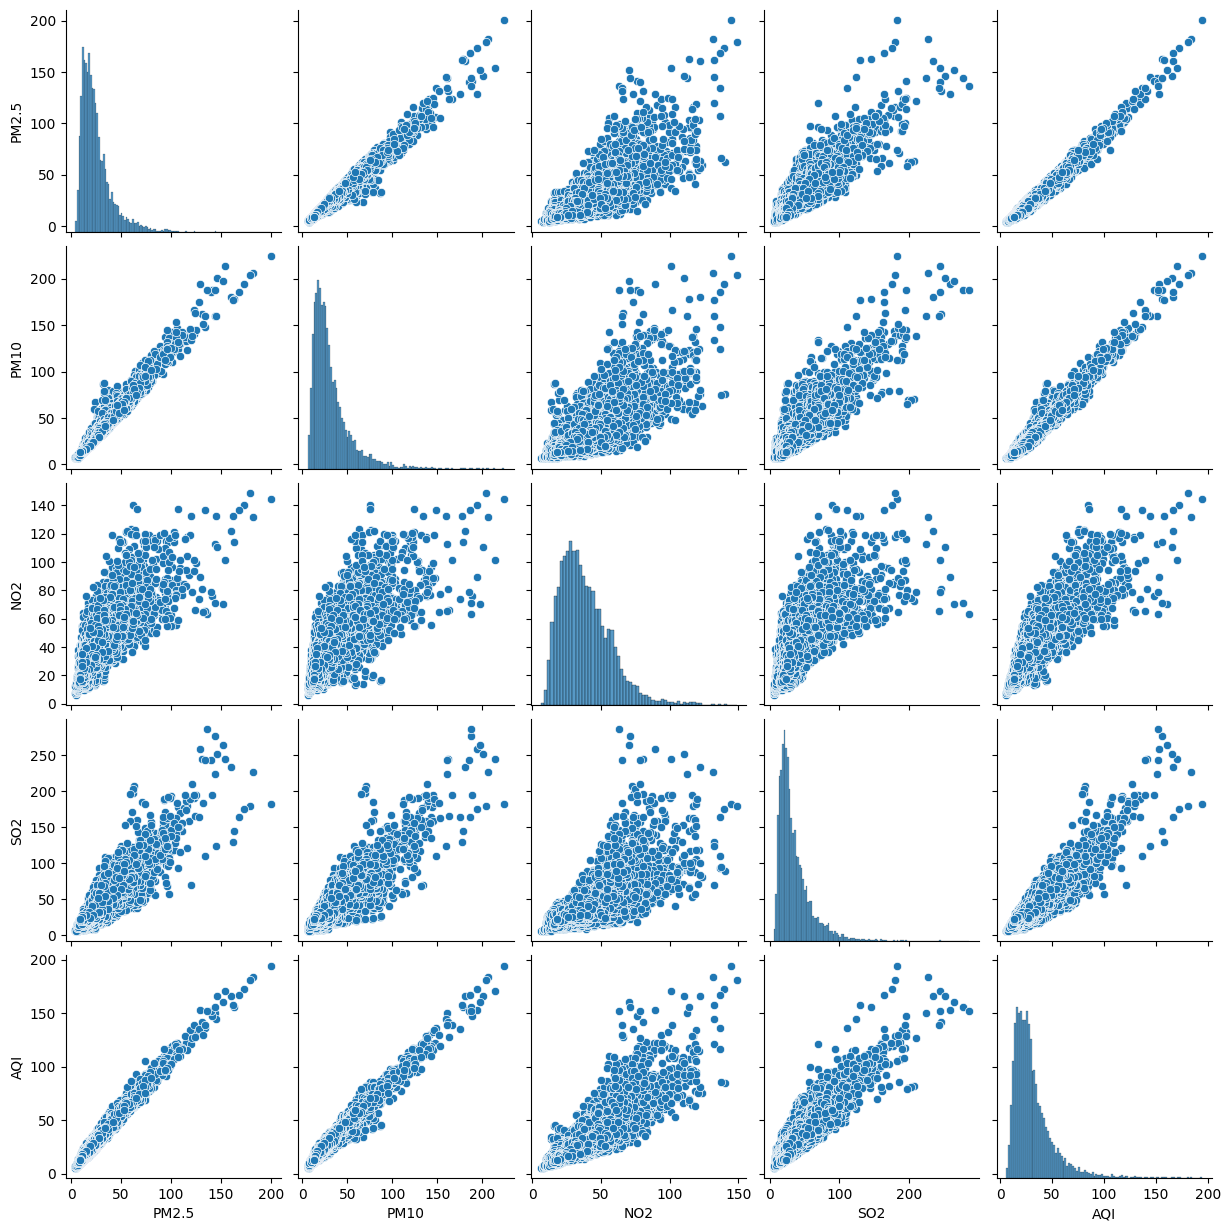

In [48]:
sns.pairplot(air_df[["PM2.5", "PM10", "NO2", "SO2", "AQI"]])
plt.show()

### Density Plot

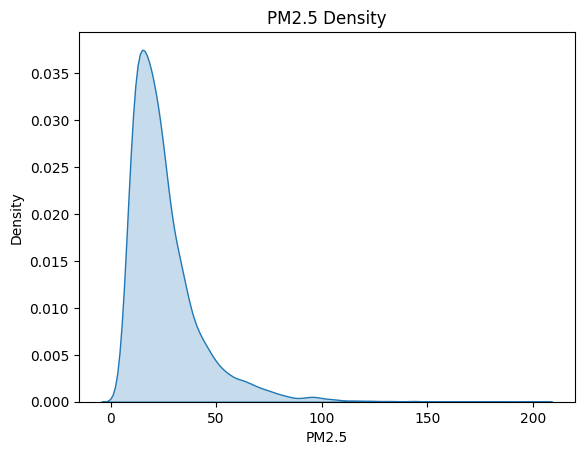

In [49]:
sns.kdeplot(air_df["PM2.5"], fill=True)
plt.title("PM2.5 Density")
plt.show()

### Joint Plot Analysis

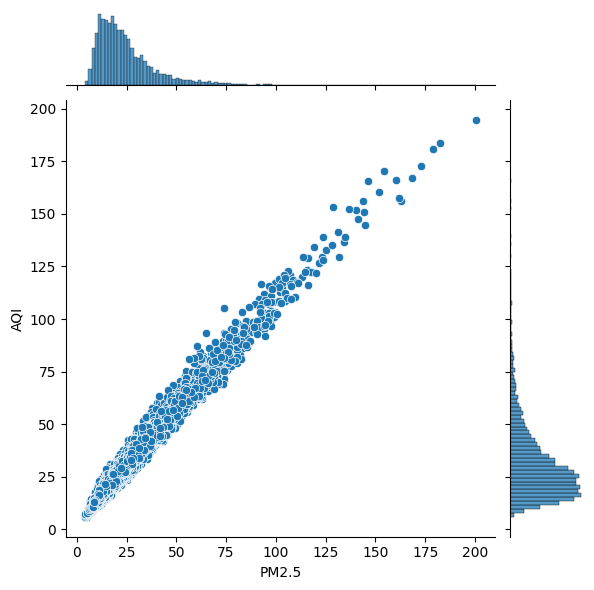

In [50]:
sns.jointplot(x="PM2.5", y="AQI", data=air_df)
plt.show()

## Time Series Analysis of AQI

In this section, we analyze how the Air Quality Index (AQI) changes over time. This helps identify pollution trends, fluctuations, and patterns in air quality.

### Data Preparation

The date column is converted into datetime format and sorted to ensure proper time-series analysis.

In [51]:

import matplotlib.pyplot as plt

air_df["Date"] = pd.to_datetime(air_df["Date"])
air_df = air_df.sort_values("Date")

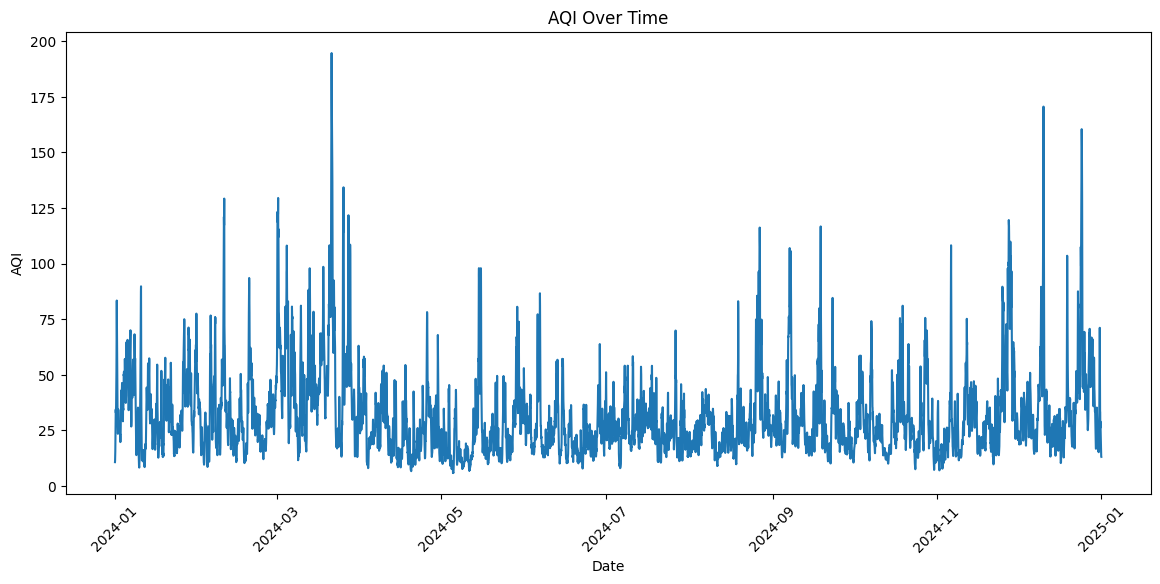

In [52]:
plt.figure(figsize=(14,6))
plt.plot(air_df["Date"], air_df["AQI"])
plt.title("AQI Over Time")
plt.xlabel("Date")
plt.ylabel("AQI")
plt.xticks(rotation=45)
plt.show()

### Smoothed AQI Trend

A rolling average is used to smooth the AQI values and highlight overall trends by reducing noise in the data.

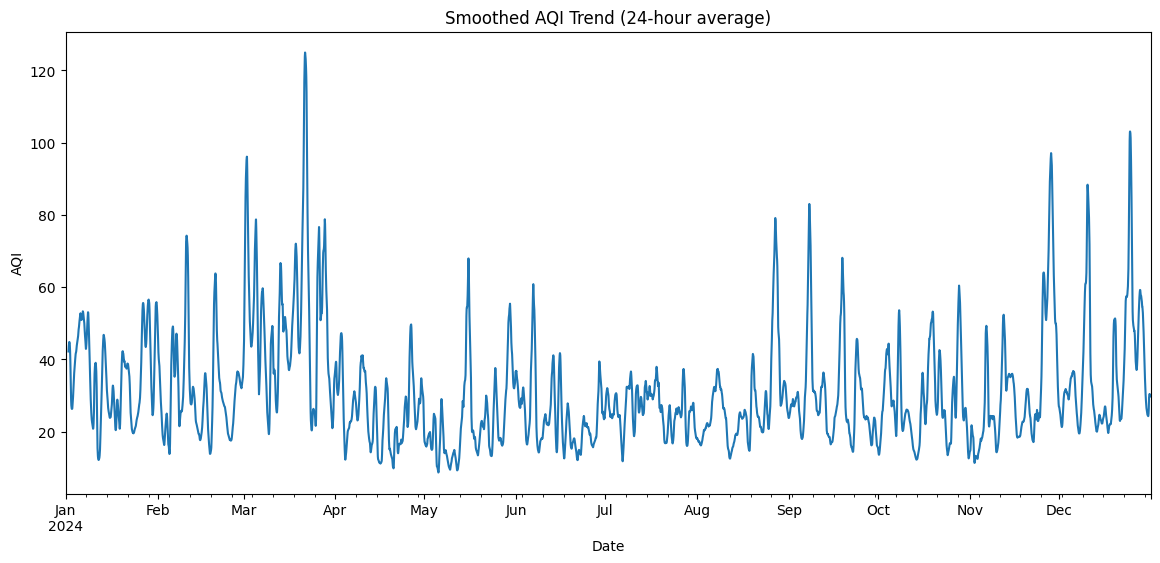

In [53]:
air_df.set_index("Date")["AQI"].rolling(24).mean().plot(figsize=(14,6))
plt.title("Smoothed AQI Trend (24-hour average)")
plt.xlabel("Date")
plt.ylabel("AQI")
plt.show()

## Final Conclusion

The exploratory data analysis of the air quality dataset provides comprehensive insights into pollution patterns, relationships among pollutants, and temporal variations in air quality.

Correlation and pairwise analysis reveal a strong positive relationship between particulate matter pollutants, particularly PM2.5 and PM10, indicating that they are likely generated from similar sources such as industrial emissions and combustion processes. Gaseous pollutants like NO2 and SO2 also show moderate relationships, suggesting interconnected emission sources.

Distribution and density plots indicate that pollutant levels are not uniformly distributed and often exhibit skewness. This suggests that pollution levels fluctuate significantly, with certain periods experiencing much higher concentrations than others.

Outlier analysis using boxplots highlights the presence of extreme values in pollutant concentrations. These spikes may correspond to sudden environmental changes, industrial activity surges, or unfavorable atmospheric conditions.

The AQI-based analysis simplifies complex pollutant data into a single interpretable metric. Higher AQI values clearly indicate deteriorating air quality and potential health risks, making it an effective indicator for monitoring pollution.

Time-series analysis of AQI demonstrates clear fluctuations over time, with noticeable peaks representing periods of high pollution. The smoothed trend further reveals underlying patterns by reducing short-term noise, providing a clearer understanding of long-term air quality behavior.

Advanced visualizations such as pairplots and joint plots confirm that AQI is strongly influenced by particulate matter, especially PM2.5. These plots also reinforce the relationships between multiple pollutants simultaneously.

Area-wise and industrial analysis indicates that industrial regions tend to exhibit higher and more variable pollution levels, emphasizing the impact of industrial activities on air quality.

Overall, the analysis highlights that air pollution is a complex phenomenon influenced by multiple interrelated factors. The combination of statistical analysis, visualization, and feature engineering provides a clear and structured understanding of air quality patterns, forming a strong foundation for further integration with energy consumption and machine health monitoring in a smart industrial system.

## Energy Consumption Analysis

In this section, we analyze energy usage patterns in an industrial environment to understand consumption behavior and identify efficiency opportunities.

### Data Understanding

The dataset contains information about energy consumption along with various operational parameters such as load type, lagging current, and power factors.

In [54]:

energy_df.head()

,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type
0,01/01/2018 00:15,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load
1,01/01/2018 00:30,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load
2,01/01/2018 00:45,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load
3,01/01/2018 01:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load
4,01/01/2018 01:15,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load


In [55]:
energy_df.shape

(35040, 11)

In [56]:
energy_df.columns

Index(['date', 'Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh',
       'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)',
       'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM',
       'WeekStatus', 'Day_of_week', 'Load_Type'],
      dtype='object')

In [57]:
energy_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   date                                  35040 non-null  object 
 1   Usage_kWh                             35040 non-null  float64
 2   Lagging_Current_Reactive.Power_kVarh  35040 non-null  float64
 3   Leading_Current_Reactive_Power_kVarh  35040 non-null  float64
 4   CO2(tCO2)                             35040 non-null  float64
 5   Lagging_Current_Power_Factor          35040 non-null  float64
 6   Leading_Current_Power_Factor          35040 non-null  float64
 7   NSM                                   35040 non-null  int64  
 8   WeekStatus                            35040 non-null  object 
 9   Day_of_week                           35040 non-null  object 
 10  Load_Type                             35040 non-null  object 
dtypes: float64(6), 

### Data Cleaning

The dataset is checked for missing values, duplicates, and data consistency to ensure reliability for analysis.

In [58]:
energy_df.duplicated().sum()

np.int64(0)

In [59]:
energy_df.isnull().sum()

date                                    0
Usage_kWh                               0
Lagging_Current_Reactive.Power_kVarh    0
Leading_Current_Reactive_Power_kVarh    0
CO2(tCO2)                               0
Lagging_Current_Power_Factor            0
Leading_Current_Power_Factor            0
NSM                                     0
WeekStatus                              0
Day_of_week                             0
Load_Type                               0
dtype: int64

### Feature Engineering

New features are created to better understand energy consumption patterns.

In [60]:
energy_df["date"] = pd.to_datetime(energy_df["date"], errors="coerce")

In [61]:
energy_df["Hour"] = energy_df["date"].dt.hour

In [62]:
energy_df["Day"] = energy_df["date"].dt.day_name()

In [63]:
energy_df["Load_Type_Code"] = energy_df["Load_Type"].astype("category").cat.codes

### Energy Consumption Distribution

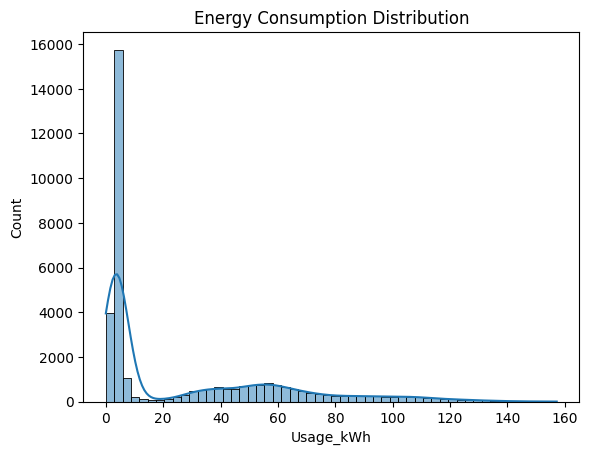

In [64]:
sns.histplot(energy_df["Usage_kWh"], kde=True)
plt.title("Energy Consumption Distribution")
plt.show()

### Energy Usage Over Time

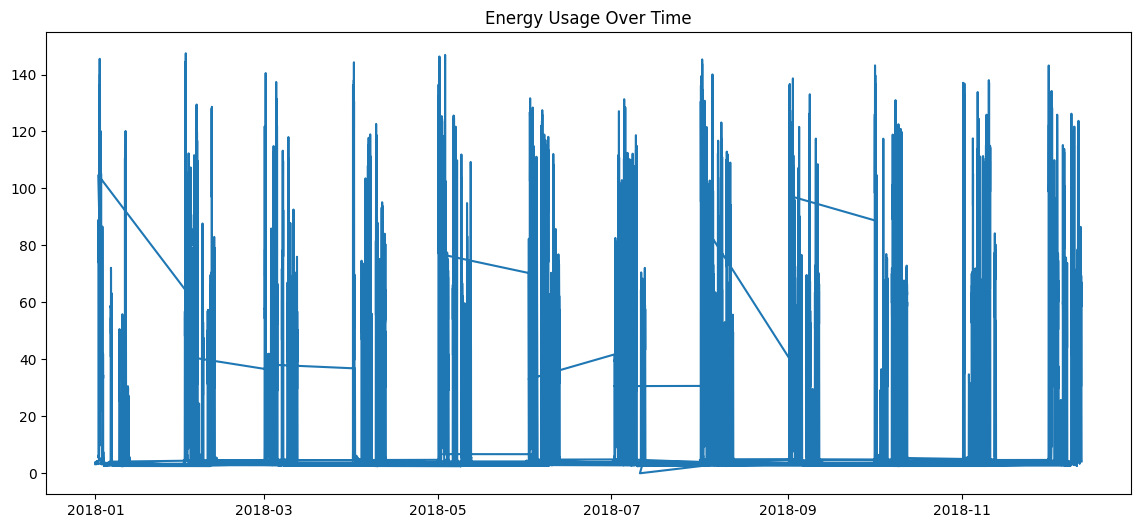

In [65]:
plt.figure(figsize=(14,6))
plt.plot(energy_df["date"], energy_df["Usage_kWh"])
plt.title("Energy Usage Over Time")
plt.show()

### Energy Consumption by Hour

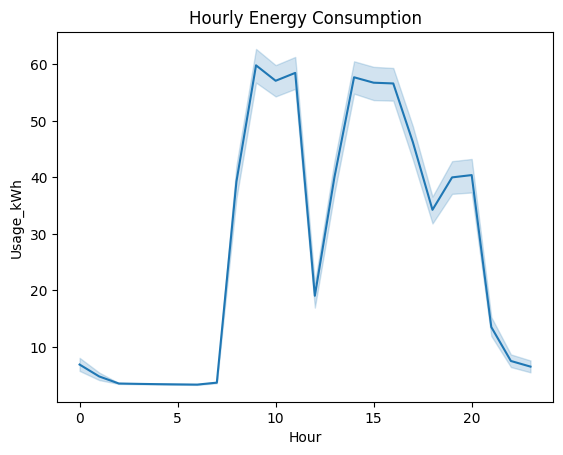

In [66]:
sns.lineplot(x="Hour", y="Usage_kWh", data=energy_df)
plt.title("Hourly Energy Consumption")
plt.show()

### Energy Consumption by Day

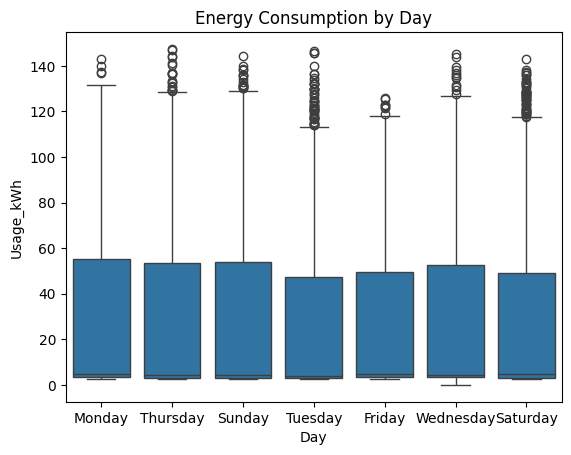

In [67]:
sns.boxplot(x="Day", y="Usage_kWh", data=energy_df)
plt.title("Energy Consumption by Day")
plt.show()

### Correlation Analysis

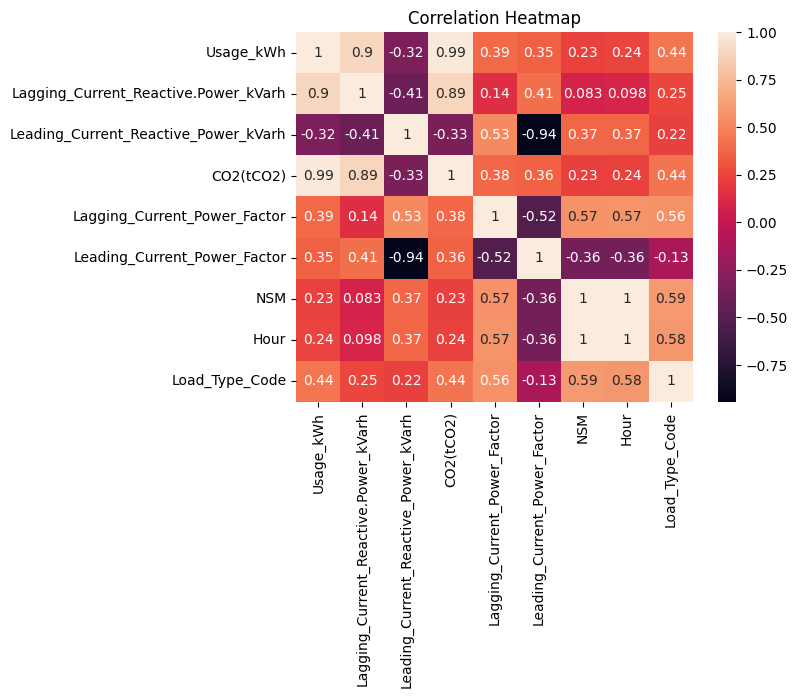

In [68]:
sns.heatmap(energy_df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

### Daily Energy Consumption Trend

This graph shows how energy consumption changes over days, helping identify increasing or decreasing trends over time.

In [69]:
daily_energy = energy_df.groupby(energy_df["date"].dt.date)["Usage_kWh"].mean()

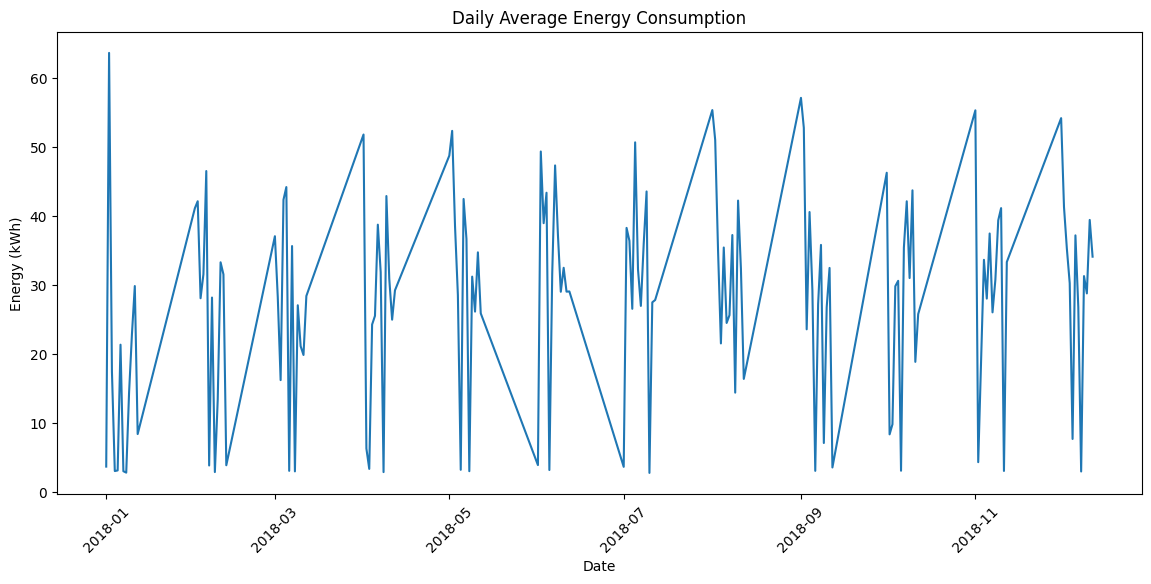

In [70]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
daily_energy.plot()
plt.title("Daily Average Energy Consumption")
plt.xlabel("Date")
plt.ylabel("Energy (kWh)")
plt.xticks(rotation=45)
plt.show()

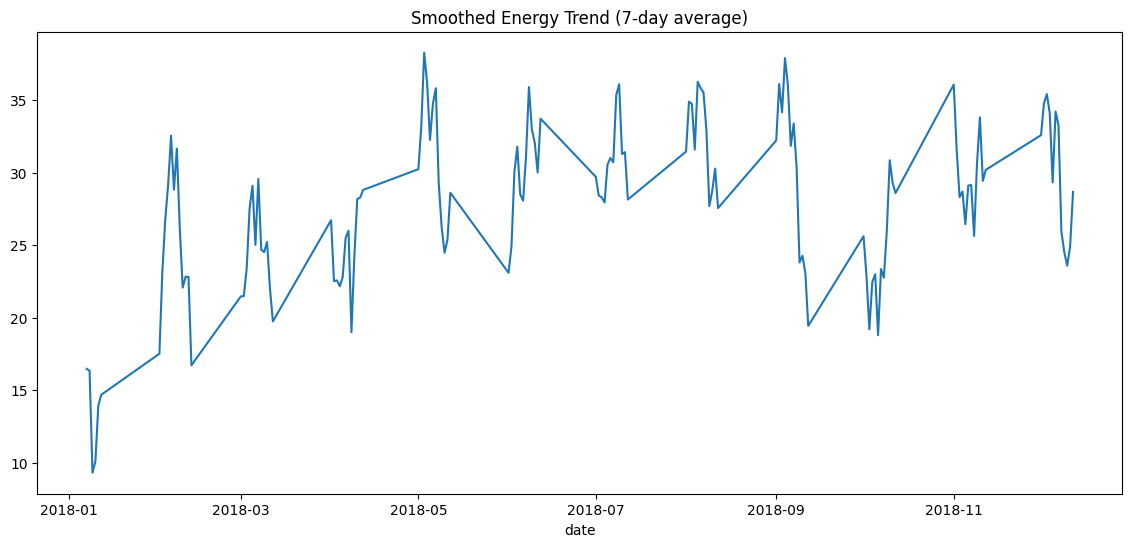

In [71]:
daily_energy.rolling(7).mean().plot(figsize=(14,6))
plt.title("Smoothed Energy Trend (7-day average)")
plt.show()

### Highest Energy Consumption Period

This analysis identifies the time period with the highest energy consumption and highlights it on the graph.

In [72]:
energy_df["date"] = pd.to_datetime(energy_df["date"])

daily_energy = energy_df.groupby(energy_df["date"].dt.date)["Usage_kWh"].mean()

In [73]:
peak_day = daily_energy.idxmax()
peak_value = daily_energy.max()

peak_day, peak_value

(datetime.date(2018, 1, 2), np.float64(63.694375))

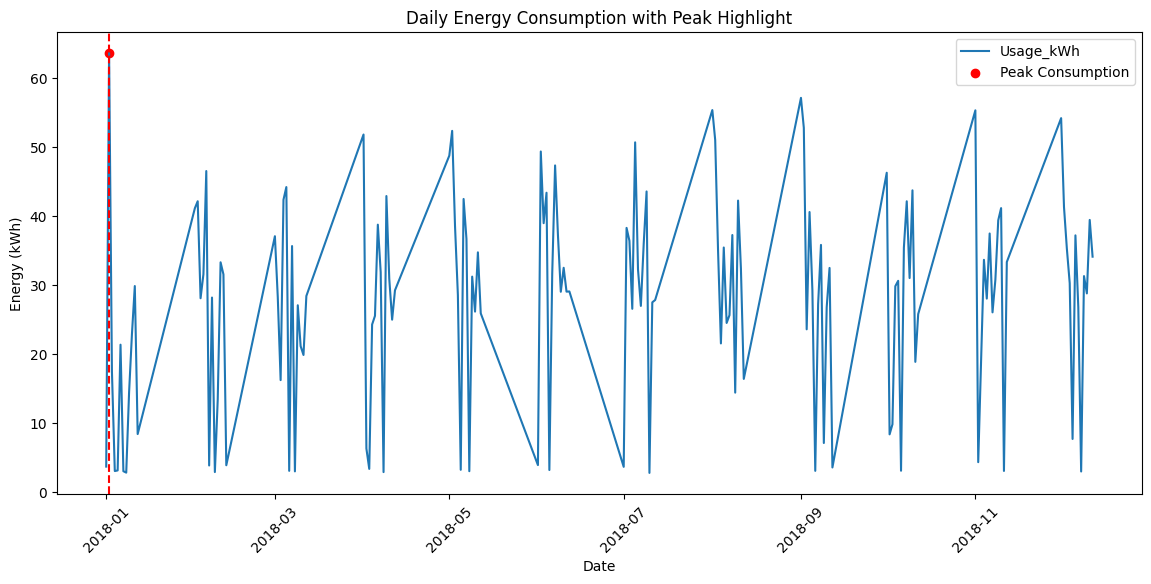

In [74]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
daily_energy.plot()

# Highlight peak
plt.scatter(peak_day, peak_value, color='red', label='Peak Consumption')
plt.axvline(x=peak_day, color='red', linestyle='--')

plt.title("Daily Energy Consumption with Peak Highlight")
plt.xlabel("Date")
plt.ylabel("Energy (kWh)")
plt.legend()
plt.xticks(rotation=45)
plt.show()

In [75]:
daily_energy.sort_values(ascending=False).head()

date
2018-01-02    63.694375
2018-09-01    57.170521
2018-08-01    55.401146
2018-11-01    55.360521
2018-12-01    54.231042
Name: Usage_kWh, dtype: float64

### Peak Hour Energy Analysis

This analysis identifies the hours of the day when energy consumption is highest and lowest, helping understand operational load patterns.

In [76]:
energy_df["Hour"] = energy_df["date"].dt.hour

In [77]:
hourly_energy = energy_df.groupby("Hour")["Usage_kWh"].mean()

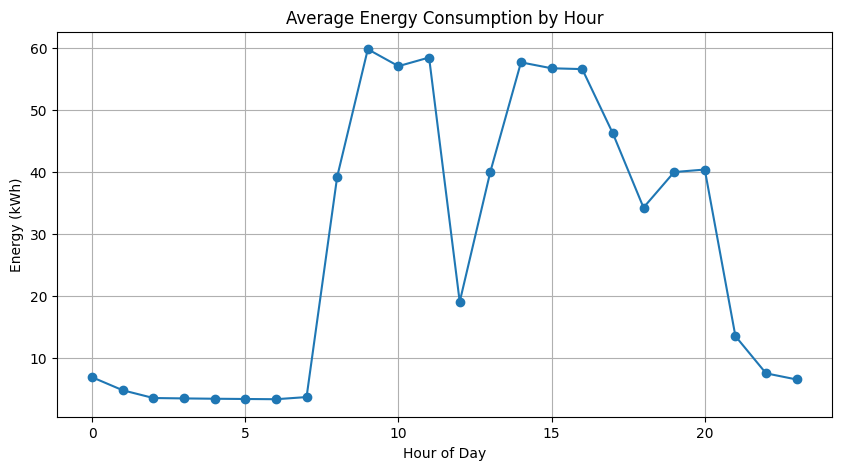

In [78]:


plt.figure(figsize=(10,5))
hourly_energy.plot(marker='o')

plt.title("Average Energy Consumption by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Energy (kWh)")
plt.grid()
plt.show()

In [79]:
peak_hour = hourly_energy.idxmax()
low_hour = hourly_energy.idxmin()

peak_hour, low_hour

(np.float64(9.0), np.float64(6.0))

### Peak and Lowest Hour Energy Analysis

This graph shows average energy consumption across different hours of the day, highlighting both the peak (highest) and lowest consumption periods.

In [80]:
energy_df["date"] = pd.to_datetime(energy_df["date"])
energy_df["Hour"] = energy_df["date"].dt.hour

hourly_energy = energy_df.groupby("Hour")["Usage_kWh"].mean()

In [81]:
peak_hour = hourly_energy.idxmax()
low_hour = hourly_energy.idxmin()

peak_value = hourly_energy.max()
low_value = hourly_energy.min()

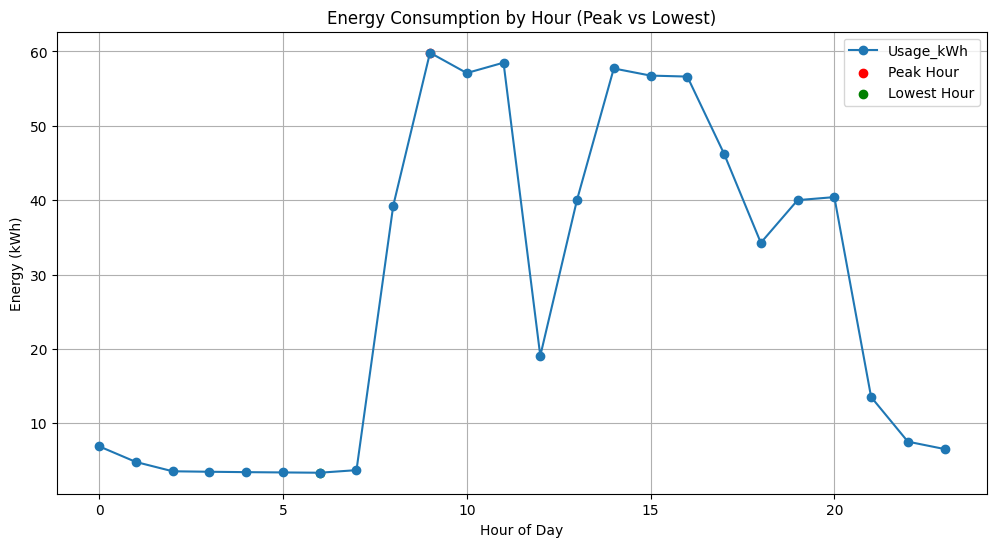

In [82]:

plt.figure(figsize=(12,6))
hourly_energy.plot(marker='o')

# Highlight peak
plt.scatter(peak_hour, peak_value, color='red', label='Peak Hour')

# Highlight lowest
plt.scatter(low_hour, low_value, color='green', label='Lowest Hour')

plt.title("Energy Consumption by Hour (Peak vs Lowest)")
plt.xlabel("Hour of Day")
plt.ylabel("Energy (kWh)")
plt.legend()
plt.grid()

plt.show()

## Final Conclusion

The energy consumption analysis provides clear insights into how industrial energy usage varies across time and operational conditions.

Time-based analysis shows that energy consumption is not constant and fluctuates significantly over days and hours. The daily trend highlights periods of increasing and decreasing energy usage, indicating variations in industrial activity.

Peak consumption analysis identifies specific days and hours where energy demand is highest. These peak periods are likely associated with maximum machine operation and production load. In contrast, low consumption periods represent reduced activity or downtime.

Hourly analysis further reveals that energy usage follows a pattern throughout the day, with certain hours consistently showing higher consumption. This indicates structured operational schedules within the industry.

The identification of both peak and lowest consumption periods is crucial for energy management. By understanding these patterns, industries can optimize energy usage, reduce costs, and improve efficiency by shifting non-critical operations to low-demand periods.

Overall, the analysis demonstrates that energy consumption is strongly influenced by time and operational behavior. These insights can be effectively used for load balancing, cost reduction, and efficient energy planning in industrial environments.

## machine health

## Machine Health Prediction

In this section, we analyze machine sensor data to detect patterns and predict potential machine failures using data analysis and machine learning techniques.

### Data Understanding

The dataset contains machine sensor readings such as temperature, vibration, pressure, and operational parameters. These features help in analyzing machine condition and predicting failures.

In [83]:
machine_df = pd.read_csv("simulated_iiot_dataset.csv")
machine_df.head()

,temperature,vibration,pressure,humidity,rotation_speed,voltage,current,oil_level,load,motor_temperature,gearbox_temperature,sound_level,fan_speed,reactive_power,active_power,machine_failure,timestamp
0,77.483571,0.639936,27.974465,30.460962,1456.825320,215.762403,4.442959,73.925925,79.669747,63.827011,61.607526,71.465461,1258.740703,50.058682,97.757590,0,1/1/2024 0:00
1,74.308678,0.592463,29.566444,35.698075,1498.439826,215.465859,4.684535,61.111595,74.963497,65.367064,63.472503,76.298551,1106.050953,52.637193,97.891653,0,1/1/2024 1:00
2,78.238443,0.505963,27.622740,37.931972,1500.900844,202.043568,4.528970,73.573728,78.276250,62.493450,62.013095,78.332260,1183.610247,41.944986,122.354274,0,1/1/2024 2:00
3,82.615149,0.435306,29.076115,49.438438,1523.631517,216.699098,4.726002,68.831380,87.147317,50.287512,65.552090,77.265555,1197.916999,45.400509,108.093109,0,1/1/2024 3:00
4,73.829233,0.569822,24.319156,42.782766,1431.657082,227.328291,4.892925,73.537289,92.778567,59.222888,70.985893,78.253433,1200.795433,49.259107,124.806509,1,1/1/2024 4:00


In [84]:
machine_df.shape

(1000, 17)

In [85]:
machine_df.columns


Index(['temperature', 'vibration', 'pressure', 'humidity', 'rotation_speed',
       'voltage', 'current', 'oil_level', 'load', 'motor_temperature',
       'gearbox_temperature', 'sound_level', 'fan_speed', 'reactive_power',
       'active_power', 'machine_failure', 'timestamp'],
      dtype='object')

In [86]:
machine_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   temperature          1000 non-null   float64
 1   vibration            1000 non-null   float64
 2   pressure             1000 non-null   float64
 3   humidity             1000 non-null   float64
 4   rotation_speed       1000 non-null   float64
 5   voltage              1000 non-null   float64
 6   current              1000 non-null   float64
 7   oil_level            1000 non-null   float64
 8   load                 1000 non-null   float64
 9   motor_temperature    1000 non-null   float64
 10  gearbox_temperature  1000 non-null   float64
 11  sound_level          1000 non-null   float64
 12  fan_speed            1000 non-null   float64
 13  reactive_power       1000 non-null   float64
 14  active_power         1000 non-null   float64
 15  machine_failure      1000 non-null   in

In [87]:
machine_df.describe()

,temperature,vibration,pressure,humidity,rotation_speed,voltage,current,oil_level,load,motor_temperature,gearbox_temperature,sound_level,fan_speed,reactive_power,active_power,machine_failure
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,75.096660,0.507084,30.017503,39.906404,1497.536318,219.532624,4.985922,70.096085,80.183418,59.939829,64.800457,74.966418,1200.436575,50.319840,100.311680,0.162000
std,4.896080,0.099745,2.950363,5.135663,49.619011,10.073892,0.512502,5.208700,10.116854,4.825616,4.852018,3.044218,48.661286,5.127844,10.074989,0.368635
min,58.793663,0.205961,20.941464,25.352757,1341.164809,191.004861,3.643694,51.558174,41.633445,40.387999,48.837173,64.873263,1060.851978,34.587189,66.704962,0.000000
25%,71.762048,0.439376,28.056001,36.312898,1465.869752,213.063072,4.622431,66.539219,73.631455,56.783329,61.565503,73.026418,1167.578101,46.849870,93.355223,0.000000
50%,75.126503,0.506308,29.999248,40.000923,1499.087900,219.571729,4.972627,70.024899,80.191240,60.021831,64.718429,74.903191,1200.553492,50.402801,100.112341,0.000000
75%,78.239719,0.572888,31.982746,43.334727,1531.956157,226.124468,5.349873,73.617006,86.772041,63.253711,68.061675,76.904721,1233.210037,53.686347,107.190268,0.000000
max,94.263657,0.819311,41.778713,56.215465,1655.645510,250.982994,6.764528,85.588406,113.773829,73.841868,79.570546,85.133305,1364.205910,67.144552,131.404229,1.000000


### Data Cleaning

The dataset is checked for missing values, duplicates, and inconsistencies to ensure data quality before analysis.

In [88]:
machine_df.isnull().sum()
machine_df.duplicated().sum()

np.int64(0)

In [89]:
machine_df = machine_df.drop_duplicates()

### Feature Engineering

New features are created to better represent machine behavior and improve predictive analysis.

In [90]:
# If vibration exists
if "Vibration" in machine_df.columns:
    machine_df["Vibration_Level"] = machine_df["Vibration"]

# Temperature category
if "Temperature" in machine_df.columns:
    machine_df["Temp_Level"] = pd.cut(machine_df["Temperature"], bins=3, labels=["Low","Medium","High"])

In [91]:
machine_df.columns

Index(['temperature', 'vibration', 'pressure', 'humidity', 'rotation_speed',
       'voltage', 'current', 'oil_level', 'load', 'motor_temperature',
       'gearbox_temperature', 'sound_level', 'fan_speed', 'reactive_power',
       'active_power', 'machine_failure', 'timestamp'],
      dtype='object')

In [92]:
machine_df["Health_Score"] = (
    machine_df["temperature"] * 0.3 +
    machine_df["vibration"] * 0.4 +
    machine_df["pressure"] * 0.3
)

In [93]:
machine_df.columns

Index(['temperature', 'vibration', 'pressure', 'humidity', 'rotation_speed',
       'voltage', 'current', 'oil_level', 'load', 'motor_temperature',
       'gearbox_temperature', 'sound_level', 'fan_speed', 'reactive_power',
       'active_power', 'machine_failure', 'timestamp', 'Health_Score'],
      dtype='object')

In [94]:
X = machine_df[["Health_Score"]]
y = machine_df["machine_failure"]

### Exploratory Data Analysis (Machine Health)

In this section, we visualize sensor behavior and understand how features relate to machine failure.

### Health Score Distribution

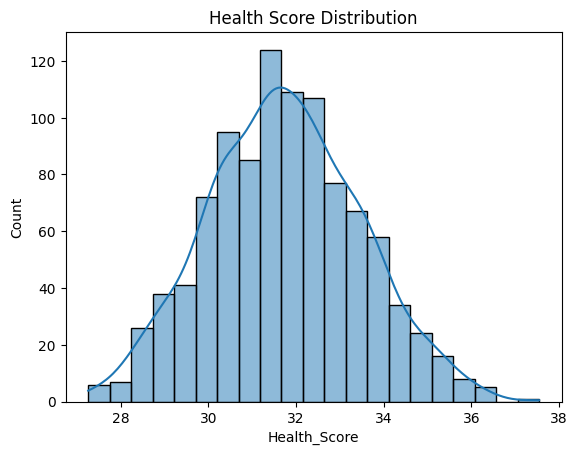

In [95]:


sns.histplot(machine_df["Health_Score"], kde=True)
plt.title("Health Score Distribution")
plt.show()

### Health Score vs Machine Failure

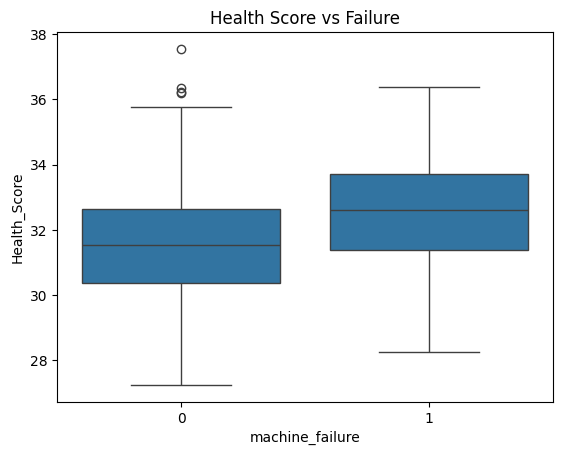

In [96]:
sns.boxplot(x="machine_failure", y="Health_Score", data=machine_df)
plt.title("Health Score vs Failure")
plt.show()

### Health Score Pattern

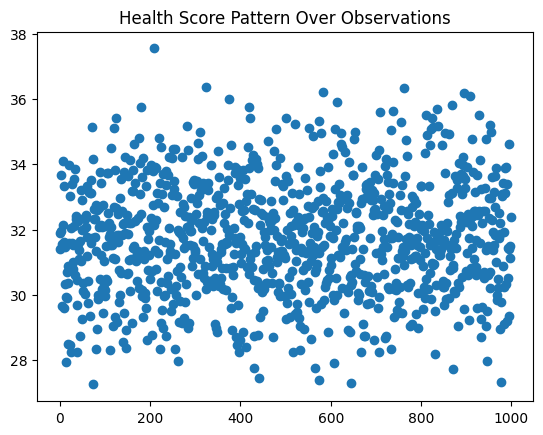

In [97]:
plt.scatter(range(len(machine_df)), machine_df["Health_Score"])
plt.title("Health Score Pattern Over Observations")
plt.show()

### Failure Distribution

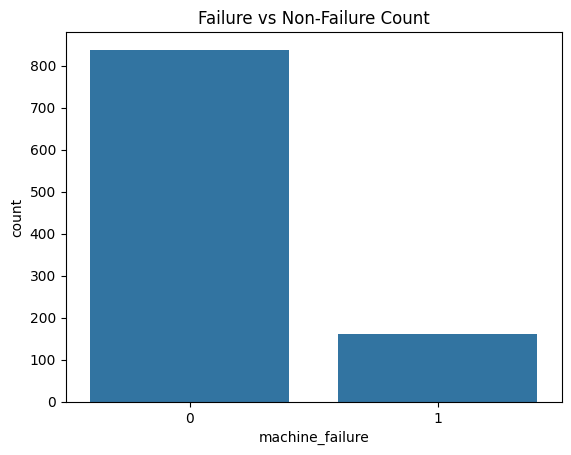

In [98]:
sns.countplot(x="machine_failure", data=machine_df)
plt.title("Failure vs Non-Failure Count")
plt.show()

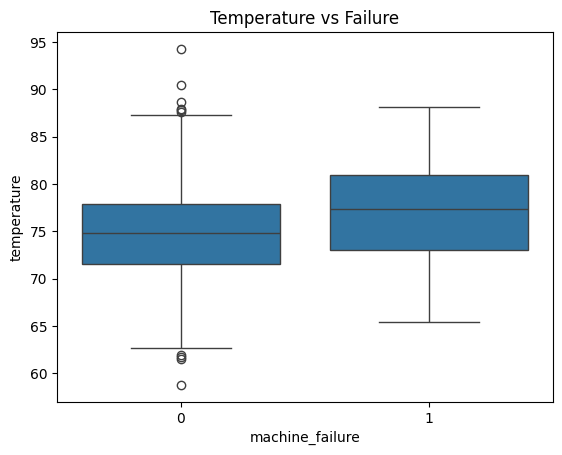

In [99]:
sns.boxplot(x="machine_failure", y="temperature", data=machine_df)
plt.title("Temperature vs Failure")
plt.show()

### EDA Summary

The analysis shows that health score is a strong indicator of machine condition. Differences between failure and non-failure cases are visible in the visualizations.

The dataset may exhibit class imbalance, and certain sensor features contribute more significantly to failure prediction. These insights are useful for building an effective machine learning model.

### Machine Learning Model for Failure Prediction

In this section, we build a machine learning model to predict machine failure based on sensor data and engineered features.

## Import Libraries

In this step, we import all necessary libraries for data analysis, visualization, and machine learning.

In [100]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [101]:
machine_df = pd.read_csv("simulated_iiot_dataset.csv")
machine_df.head()

,temperature,vibration,pressure,humidity,rotation_speed,voltage,current,oil_level,load,motor_temperature,gearbox_temperature,sound_level,fan_speed,reactive_power,active_power,machine_failure,timestamp
0,77.483571,0.639936,27.974465,30.460962,1456.825320,215.762403,4.442959,73.925925,79.669747,63.827011,61.607526,71.465461,1258.740703,50.058682,97.757590,0,1/1/2024 0:00
1,74.308678,0.592463,29.566444,35.698075,1498.439826,215.465859,4.684535,61.111595,74.963497,65.367064,63.472503,76.298551,1106.050953,52.637193,97.891653,0,1/1/2024 1:00
2,78.238443,0.505963,27.622740,37.931972,1500.900844,202.043568,4.528970,73.573728,78.276250,62.493450,62.013095,78.332260,1183.610247,41.944986,122.354274,0,1/1/2024 2:00
3,82.615149,0.435306,29.076115,49.438438,1523.631517,216.699098,4.726002,68.831380,87.147317,50.287512,65.552090,77.265555,1197.916999,45.400509,108.093109,0,1/1/2024 3:00
4,73.829233,0.569822,24.319156,42.782766,1431.657082,227.328291,4.892925,73.537289,92.778567,59.222888,70.985893,78.253433,1200.795433,49.259107,124.806509,1,1/1/2024 4:00


##  Feature Selection

We select important features affecting machine health and define the target variable.

In [102]:
features = ["temperature", "vibration", "pressure"]

X = machine_df[features]
y = machine_df["machine_failure"]

##  Train-Test Split

We divide the dataset into training and testing sets to evaluate model performance.

In [103]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

##  Model Training

We train a Random Forest Classifier to predict machine failure.

In [104]:
model = RandomForestClassifier()
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## : Prediction

We use the trained model to predict outcomes on test data.

In [105]:
y_pred = model.predict(X_test)

##  Accuracy Evaluation

We evaluate the model performance using accuracy score.

In [106]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.805


##  Classification Report

We analyze precision, recall, and F1-score for deeper evaluation.

In [107]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.93      0.89       168
           1       0.29      0.16      0.20        32

    accuracy                           0.81       200
   macro avg       0.57      0.54      0.55       200
weighted avg       0.76      0.81      0.78       200



##  Confusion Matrix

We visualize correct and incorrect predictions using a confusion matrix.

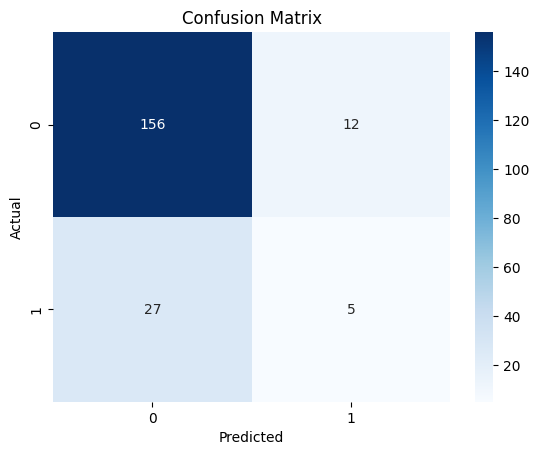

In [108]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

##  Feature Importance

We identify which features contribute most to machine failure prediction.

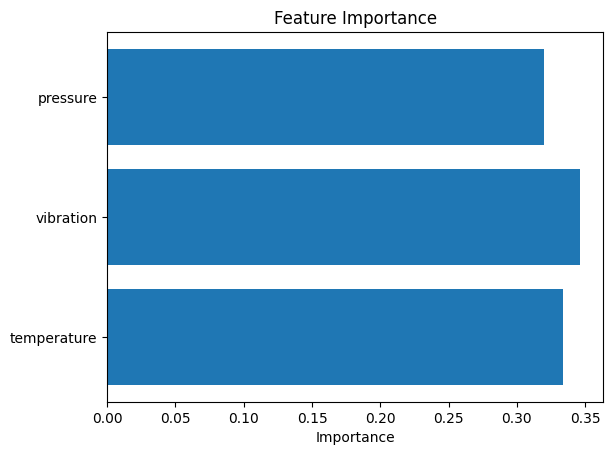

In [112]:
importances = model.feature_importances_
feature_names = X.columns

plt.barh(feature_names, importances)
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.show()

## Conclusion

The machine learning model successfully predicts machine failure based on key features such as temperature, vibration, and pressure. The Random Forest model provides good accuracy and helps identify the most influential factors affecting machine health.

In [114]:
import os

os.makedirs("models", exist_ok=True)
joblib.dump(model, "models/machine_health_model.pkl")

['models/machine_health_model.pkl']